In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import iradon

In [16]:
freq = 1295e6
c= 299792458
pri = 19.7e-3
cpi = 128

In [14]:
spec_0 = np.load('/share/nas2/pryder/tumbling_git/spectrogram___intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_1 = np.load('/share/nas2/pryder/tumbling_git/spectrogram_a_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_2 = np.load('/share/nas2/pryder/tumbling_git/spectrogram_b_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_3 = np.load('/share/nas2/pryder/tumbling_git/spectrogram_c_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
combined_spec = np.hstack((spec_0, spec_1, spec_2, spec_3))
combined_spec.shape

(256, 424)

In [17]:
time = np.arange(combined_spec.shape[1])*pri*cpi
period = 15.1
period_fraction = (time/period)%10
angles = 360 * period_fraction

In [10]:
img = iradon(combined_spec, angles, circle=True, filter_name='hamming')

In [11]:
wv = c / freq
dx = c / (2 * 8e6)                  # Range pixel resolution - c/2bandwidth
dy = wv / (2 * 0.01)   # Cross-range pixel resolution - λ/2beamwidth

N_row = combined_spec.shape[1]
M_col = combined_spec.shape[1]
range_axis = (np.arange(N_row) - (N_row / 2)) * dx
cross_range_axis = (np.arange(M_col) - (M_col / 2)) * dy

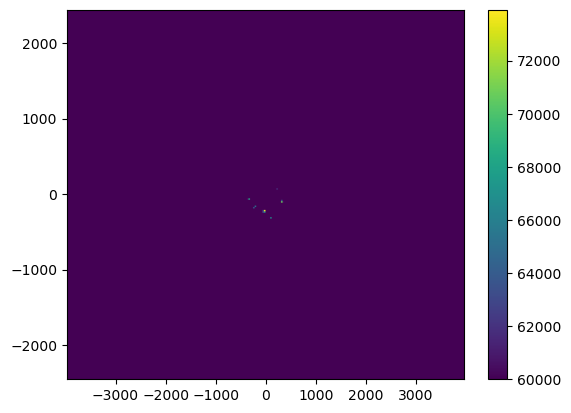

In [ ]:
plt.imshow(img, origin='lower', aspect='auto', vmin=60000, extent=[range_axis[0], range_axis[-1], cross_range_axis[0], cross_range_axis[-1]])
plt.xlim(-1000, 1000)
plt.ylim(-1000, 1000)
plt.colorbar()
plt.show()

In [13]:
np.max(img)

np.float64(73916.57269984504)

### Making this into a function

In [44]:
def make_isar_image(time, period, freq=1295e6, bw=8e6, beamwidth=0.01, filter='ramp', plot=True, verbose=False):
    '''
    Inputs:
        time: array of times corresponding to each strip of spectrogram (s)
        period: rotation period (s)
        freq: central frequency (Hz)
        bw: bandwidth (Hz)
        beamwidth: beamwidth (not sure, maybe this is where it's going wrong)
        filter: filter to use for iradon transform
        plot: if True, plot will be made
        verbose: if True, outputs will be printed

    Outputs:
        peak: maximum power in image
        snr: peak to median ratio
        '''
    period_fraction = (time/period)%10
    angles = 360 * period_fraction
    img = iradon(combined_spec, angles, circle=True, filter_name=filter)
    wv = c / freq
    dx = c / (2 * bw)                  # Range pixel resolution - c/2bandwidth
    dy = wv / (2 * beamwidth)   # Cross-range pixel resolution - λ/2beamwidth

    N_row = combined_spec.shape[1]
    M_col = combined_spec.shape[1]
    range_axis = (np.arange(N_row) - (N_row / 2)) * dx
    cross_range_axis = (np.arange(M_col) - (M_col / 2)) * dy
    if plot==True:
        plt.imshow(img, origin='lower', aspect='auto', vmin=60000, extent=[range_axis[0], range_axis[-1], cross_range_axis[0], cross_range_axis[-1]])
        plt.xlim(-1000, 1000)
        plt.ylim(-1000, 1000)
        plt.colorbar()
        plt.show()
    peak = np.max(img)
    noise = 60000 #np.mean(img)
    # print(noise)
    snr = peak/noise
    if verbose ==True:
        print('peak: ', peak)
        print('snr: ', snr)
    return peak, snr

In [ ]:
period = 15.5
best_period = 0
best_peak = 0
period_history = []
peak_history = []
snr_history = []
for i in range(2000):
    p, n = make_isar_image(time, period, plot = False,verbose=False)
    print('Trying period: ', period)
    period_history.append(period)
    peak_history.append(p)
    snr_history.append(n)
    if p>best_peak:
        best_peak = p
        best_period = period
        print('Period updated')
    else:
        print('No improvement')
    period += 0.0001

p, n = make_isar_image(time, best_period)
print('Best period: ', best_period)
plt.plot(period_history, peak_history)
plt.xlabel('Period (s)')
plt.ylabel('Peak')
plt.show()
plt.plot(period_history, snr_history)
plt.xlabel('Period (s)')
plt.ylabel('SNR')
plt.show()


Trying period:  15.5
Period updated
Trying period:  15.5001
No improvement
Trying period:  15.5002
No improvement
Trying period:  15.5003
No improvement
Trying period:  15.500399999999999
No improvement
Trying period:  15.500499999999999
No improvement
Trying period:  15.500599999999999
No improvement
Trying period:  15.500699999999998
No improvement
Trying period:  15.500799999999998
No improvement
Trying period:  15.500899999999998
No improvement
Trying period:  15.500999999999998
No improvement
Trying period:  15.501099999999997
No improvement
Trying period:  15.501199999999997
No improvement
Trying period:  15.501299999999997
No improvement
Trying period:  15.501399999999997
No improvement
Trying period:  15.501499999999997
No improvement
Trying period:  15.501599999999996
No improvement
Trying period:  15.501699999999996
No improvement
Trying period:  15.501799999999996
No improvement
Trying period:  15.501899999999996
No improvement
Trying period:  15.501999999999995
No improveme

In [76]:
from scipy.signal import find_peaks
peaks, ppp = find_peaks(snr_history, height=2.28)
print(peaks)
period_history[15]

[ 15 146 301]


2.5000000000000013